<a href="https://colab.research.google.com/github/vanadhisivakumar-source/Fundamental-Data-Science-Analytics-projects/blob/main/cross%20validation%20with%20linear%20regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import requests
import pandas as pd

# URL of the raw CSV file on GitHub
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

# Path where the file will be saved locally
file_path = "/tmp/Housing.csv"

# Download the file
response = requests.get(url)
response.raise_for_status()  # Check for any request errors

with open(file_path, "wb") as f:
    f.write(response.content)

print(f"Dataset downloaded successfully to {file_path}")

# Load dataset
housing = pd.read_csv(file_path)

Dataset downloaded successfully to /tmp/Housing.csv


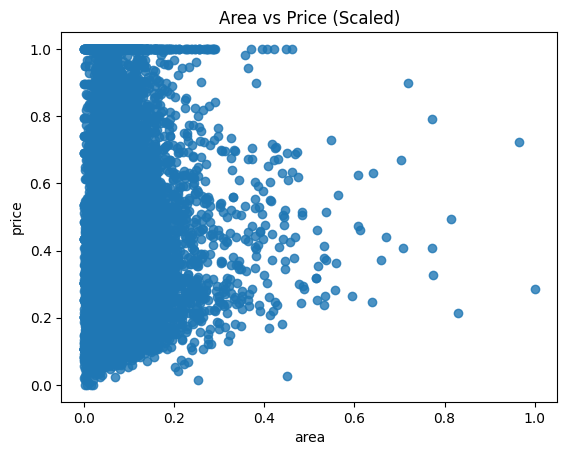

Training R^2: 0.01804590238025272
Test R^2: 0.017844714698483255


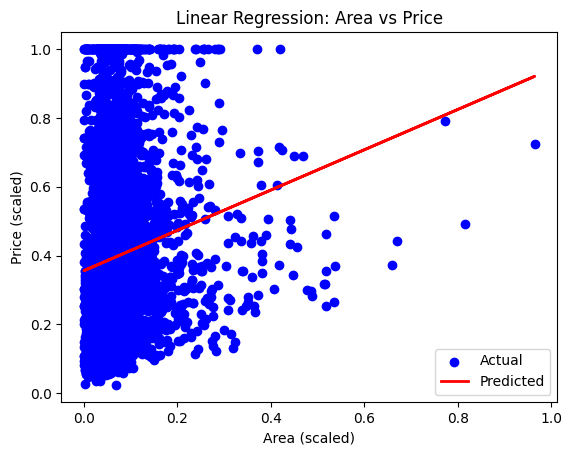

In [4]:
# Import libraries (remaining ones)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

# Filter only relevant columns for regression
df = housing.loc[:, ['total_rooms', 'median_house_value']]

# Rename columns for clarity as per original problem statement (area, price)
df.rename(columns={'total_rooms': 'area', 'median_house_value': 'price'}, inplace=True)

# Scale the variables
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

# Convert back to DataFrame
df = pd.DataFrame(df_scaled, columns=['area', 'price'])

# Visualize area-price relationship
sns.regplot(x="area", y="price", data=df, fit_reg=False)
plt.title("Area vs Price (Scaled)")
plt.show()

# Train-test split
df_train, df_test = train_test_split(df, train_size=0.7, test_size=0.3, random_state=10)

# Split into X and y
X_train = df_train['area'].values.reshape(-1, 1)
y_train = df_train['price'].values

X_test = df_test['area'].values.reshape(-1, 1)
y_test = df_test['price'].values

# Fit linear regression model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predictions
y_pred = linreg.predict(X_test)

# Evaluate performance
print("Training R^2:", linreg.score(X_train, y_train))
print("Test R^2:", linreg.score(X_test, y_test))

# Plot regression line
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel("Area (scaled)")
plt.ylabel("Price (scaled)")
plt.title("Linear Regression: Area vs Price")
plt.legend()
plt.show()